In [1]:
import rasterio
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from multiprocessing import Pool
import cv2
from datetime import datetime
import time
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2, transforms
# from torchvision.extension.

from sklearn.model_selection import train_test_split

from torchviz import make_dot
from torch.utils.tensorboard import SummaryWriter

# Set the default figure size for all plots
plt.rcParams["figure.figsize"] = (9, 8) # You can change the values (width, height) as needed

# You can also set other parameters, for example:
# plt.rcParams["font.size"] = 12
# plt.rcParams["axes.titlesize"] = 14
# plt.rcParams["axes.labelsize"] = 12
# plt.rcParams["xtick.labelsize"] = 10
# plt.rcParams["ytick.labelsize"] = 10
# plt.rcParams["legend.fontsize"] = 10

2025-10-15 10:08:55.821388: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-15 10:08:56.103462: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-15 10:08:57.154690: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
# Directory with GeoTIFF files
GEOTIFF_DIR = '../../CHIRPS_daily_India'
VERBOSE=0
BANDS=1
DO_TRAINING=True

In [5]:
def load_geotiff(file_path):
    try:
        # Extract date from filename (e.g., "CHIRPS_daily_2024-06-19.tif")
        filename = os.path.basename(file_path)
        date_str = filename.split("_")[-1].replace(".tif", "")  # Get "2024-06-19"
        date_key = datetime.strptime(date_str, "%Y-%m-%d").date()  # Parse as datetime.date

        # Open GeoTIFF and read data
        with rasterio.open(file_path) as dataset:
            data = dataset.read(BANDS)  # Read all bands, shape: (bands, height, width)
            # Optionally, read single band: data = dataset.read(1) for shape (height, width)

        return date_key, data, file_path
    except Exception as e:
        print(f"Failed to load {file_path}: {e}")
        return None, None, file_path

# Get list of GeoTIFF files
geotiff_files = glob.glob(os.path.join(GEOTIFF_DIR, "CHIRPS_daily_*.tif"))

# Use multiprocessing to load files in parallel
with Pool() as pool:
    results = pool.map(load_geotiff, geotiff_files)

# Create dictionary from results
data_dict = {}
for date_key, data, file_path in results:
    if date_key is not None and data is not None:
        data_dict[date_key] = data
        print(f"Loaded {file_path} for date {date_key}")
    else:
        print(f"Skipped {file_path} due to loading error")

Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-04-10.tif for date 1983-04-10
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-03-22.tif for date 1983-03-22
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-03-26.tif for date 1983-03-26
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-04-08.tif for date 1983-04-08
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-04-01.tif for date 1983-04-01
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-04-17.tif for date 1983-04-17
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-03-14.tif for date 1983-03-14
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-02-28.tif for date 1983-02-28
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-03-19.tif for date 1983-03-19
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-04-16.tif for date 1983-04-16
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-04-21.tif for date 1983-04-21
Loaded ../../CHIRPS_daily_India/CHIRPS_daily_1983-03-20.tif for date 1983-03-20
Loaded ../../CHIRPS_daily_India/CHIRPS_d

### Preparing dataset

In [6]:
dates = list(data_dict.keys())
high_res_images = list(data_dict.values())

In [7]:
def trasform_image(image):
    # Fill up nan values in every image of high_res_images list
    image[np.isnan(image)] = 0
    # Perform square root transformation
    # image = image**0.5
    # Min-max rescaling
    # m, M = -1, 1
    # image = m + (image - image.min())/(image.max() - image.min())*(M - m)
    image = cv2.resize(image, (512, 512), interpolation=cv2.INTER_AREA)
    return image

In [8]:
for i in range(len(high_res_images)):
    high_res_images[i] = trasform_image(high_res_images[i])

In [9]:
low_res_images = []
for image in high_res_images:
    h, w = image.shape
    SCALE_FACTOR = 5
    new_h, new_w = h // SCALE_FACTOR, w // SCALE_FACTOR
    low_res = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    low_res_images.append(low_res)
low_res_images = np.array(low_res_images)

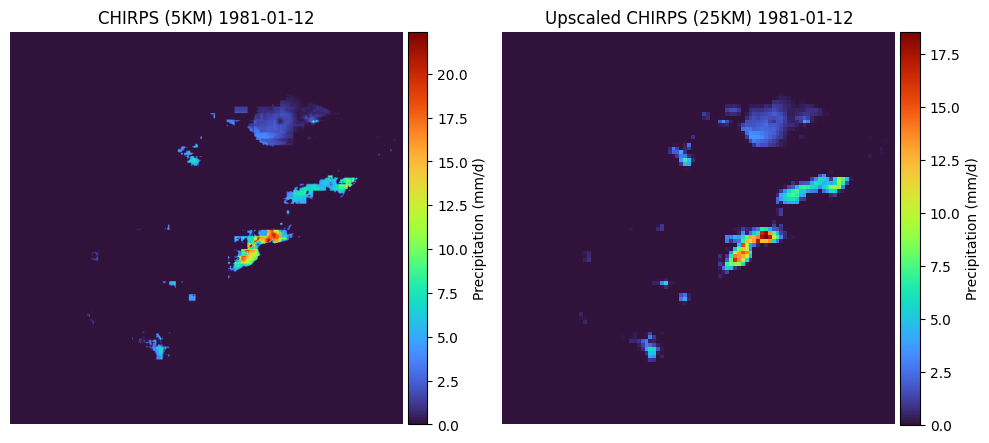

In [10]:
i = -8
high_res_image = np.copy(high_res_images[i])
low_res_image = np.copy(low_res_images[i])

fig, ax = plt.subplots(1, 2, figsize=(10,6))
image_0 = ax[0].imshow(high_res_image, cmap="turbo")
ax[0].set_title(f"CHIRPS (5KM) {dates[i]}")
ax[0].set_axis_off()

divider = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(image_0, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

image_1 = ax[1].imshow(low_res_image, cmap="turbo")
ax[1].set_title(f"Upscaled CHIRPS (25KM) {dates[i]}")
ax[1].set_axis_off()

divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(image_1, cax=cax, orientation="vertical", label="Precipitation (mm/d)");

plt.tight_layout()
# high_res_image.shape, low_res_image.shape

### GAN Model

#### Prepare data

In [11]:
class ImageDataset(Dataset):
    def __init__(self, low_res_images, high_res_images, transform=None):
        self.low_res_images = low_res_images
        self.high_res_images = high_res_images
        self.low_res_transform = transform
        # self.high_res_transform = v2.Compose([
        #     v2.ToImage(),
        #     v2.ToDtype(torch.float32, scale=True)
        # ])
        self.transform = transforms.Compose([
            transforms.ToTensor(),  # Picture to numbers
            transforms.Normalize((0.5,), (0.5,))  # For one channel, numbers between -1 and 1
        ])

    def __len__(self):
        return len(self.low_res_images)

    def __getitem__(self, index):
        low_res_image = self.low_res_images[index]
        high_res_image = self.high_res_images[index]
        low_res_image = cv2.resize(low_res_image, (512, 512), interpolation=cv2.INTER_AREA)
        # if self.low_res_transform:
        #     low_res_image = self.low_res_transform(low_res_image)
        # high_res_image = self.high_res_transform(high_res_image)
        low_res_image = self.transform(low_res_image)
        high_res_image = self.transform(high_res_image)

        return low_res_image, high_res_image

#### Build models

#### Generator

In [12]:
class Generator(nn.Module):
    def __init__(self, in_channels):
        super(Generator, self).__init__()

        # Down part (shrink picture to learn fatures)
        self.down1 = nn.Sequential(nn.Conv2d(in_channels, 64, 4, 2, 1), nn.LeakyReLU(0.2))  # 1 channel input
        self.down2 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2))
        self.down3 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2))
        self.down4 = nn.Sequential(nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2))
        
        # Up (build back with skips)
        self.up1 = nn.Sequential(nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU())
        self.up2 = nn.Sequential(nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU())
        self.up3 = nn.Sequential(nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU())
        self.up4 = nn.Sequential(nn.ConvTranspose2d(128, in_channels, 4, 2, 1), nn.Tanh())  # 1 channel output
        
    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        
        u1 = self.up1(d4)
        u2 = self.up2(torch.cat([u1, d3], 1))  # Skip connection
        u3 = self.up3(torch.cat([u2, d2], 1))
        u4 = self.up4(torch.cat([u3, d1], 1))

        return u4

#### Discriminator

In [13]:
class Discriminator(nn.Module):
    def __init__(self, in_channels):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels*2, 64, 4, 2, 1), nn.LeakyReLU(0.2),  # 2 channels: blurry + sharp/fake
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 1, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1, 4, 1, 1), nn.Sigmoid()  # Real/fake per patch
        )

    def forward(self, x, y):
        return self.model(torch.cat([x, y], 1)) # combine blurry (x) and nice/faake (y)

#### Train the GAN

In [14]:
x = low_res_images
y = high_res_images

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=69)

In [16]:
IN_CHANNELS = 1
LEARNING_RATE = 2e-3
BATCH_SIZE = 16
EPOCHS = 100

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator(IN_CHANNELS).to(device)
discriminator = Discriminator(IN_CHANNELS).to(device)

### Model Visualization

In [16]:
# x = x_train[0]
# x = cv2.resize(x, (512,512), interpolation=cv2.INTER_CUBIC)
# x_tensor = v2.ToTensor()(x).unsqueeze(0).to(device)
# x_tensor = v2.Normalize((0.5,), (0.5,))(x_tensor)

# Generate the dot graph
# dot = make_dot(generator(x_tensor), params=dict(generator.named_parameters()))

# Save the graph as a PDF
# dot.render("model_visualization", format="pdf")

In [17]:
# writer = SummaryWriter('./run_logs')

# # Add graph to TensorBoard
# writer.add_graph(generator, x_tensor)

# # Close the writer
# writer.close()

In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        # v2.Resize((128, 128), interpolation=v2.InterpolationMode.BICUBIC),
        # v2.GaussianNoise()
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]
)

dataset = ImageDataset(x_train, y_train, transform)
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True)

gan_loss = nn.BCELoss() # Binary Cross Entropy. For real/fake game
l1_loss = nn.L1Loss() # To make generated close to real
mse_loss = nn.MSELoss()

g_optimizer = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

In [ ]:
d_loss_history = []
g_loss_history = []
start_time = time.time()
if DO_TRAINING:
    for epoch in range(EPOCHS):
        # epoch_start_time = time.time()
        for low, high in tqdm(dataloader,  desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True, colour="#42a5f5"):
            low, high = low.to(device), high.to(device)

            # Train Discriminator (judge real vs fake)
            d_optimizer.zero_grad()
            fake = generator(low)
            real_pred = discriminator(low, high)
            fake_pred = discriminator(low, fake.detach())
            d_real_loss = gan_loss(real_pred, torch.ones_like(real_pred))
            d_fake_loss = gan_loss(fake_pred, torch.zeros_like(fake_pred))
            d_loss = (d_real_loss + d_fake_loss)
            d_loss.backward()
            d_optimizer.step()

            # Train Generator (make better fakes)
            g_optimizer.zero_grad()
            fake_pred = discriminator(low, fake)
            g_gan_loss = gan_loss(fake_pred, torch.ones_like(fake_pred)) + 100 * l1_loss(fake, high)
            g_l1_loss = l1_loss(fake, high) * 100
            g_loss = g_gan_loss + g_l1_loss
            # g_gan_loss = gan_loss(fake_pred, torch.ones_like(fake_pred))
            # g_mse_loss = mse_loss(fake, high)
            # g_loss = (g_gan_loss + g_gan_loss) * 0.5
            g_loss.backward()
            g_optimizer.step()
            
        g_loss_history.append(g_loss.item())
        d_loss_history.append(d_loss.item())
        # epoch_end_time = time.time()
        # epoch_time = (epoch_end_time - epoch_start_time)
        # print(f"{epoch_time:.0f}s, D_loss: {d_loss.item():0.3f}, G_loss: {g_loss.item():0.3f}")
        tqdm.write(f"D_loss: {d_loss.item():0.3f} G_loss: {g_loss.item():0.3f}")
end_time = time.time()
training_time = (end_time - start_time)/60.0
print(f"Total Training time = {training_time:.0f}m")

In [62]:
# Save the Generator
current_time = datetime.now()
year = current_time.year
month = current_time.month
day = current_time.day
current_date = f"{year}-{month}-{day}"

In [ ]:
if DO_TRAINING:
    torch.save(generator.state_dict(), f'final_generator_weights_{current_date}.pth')

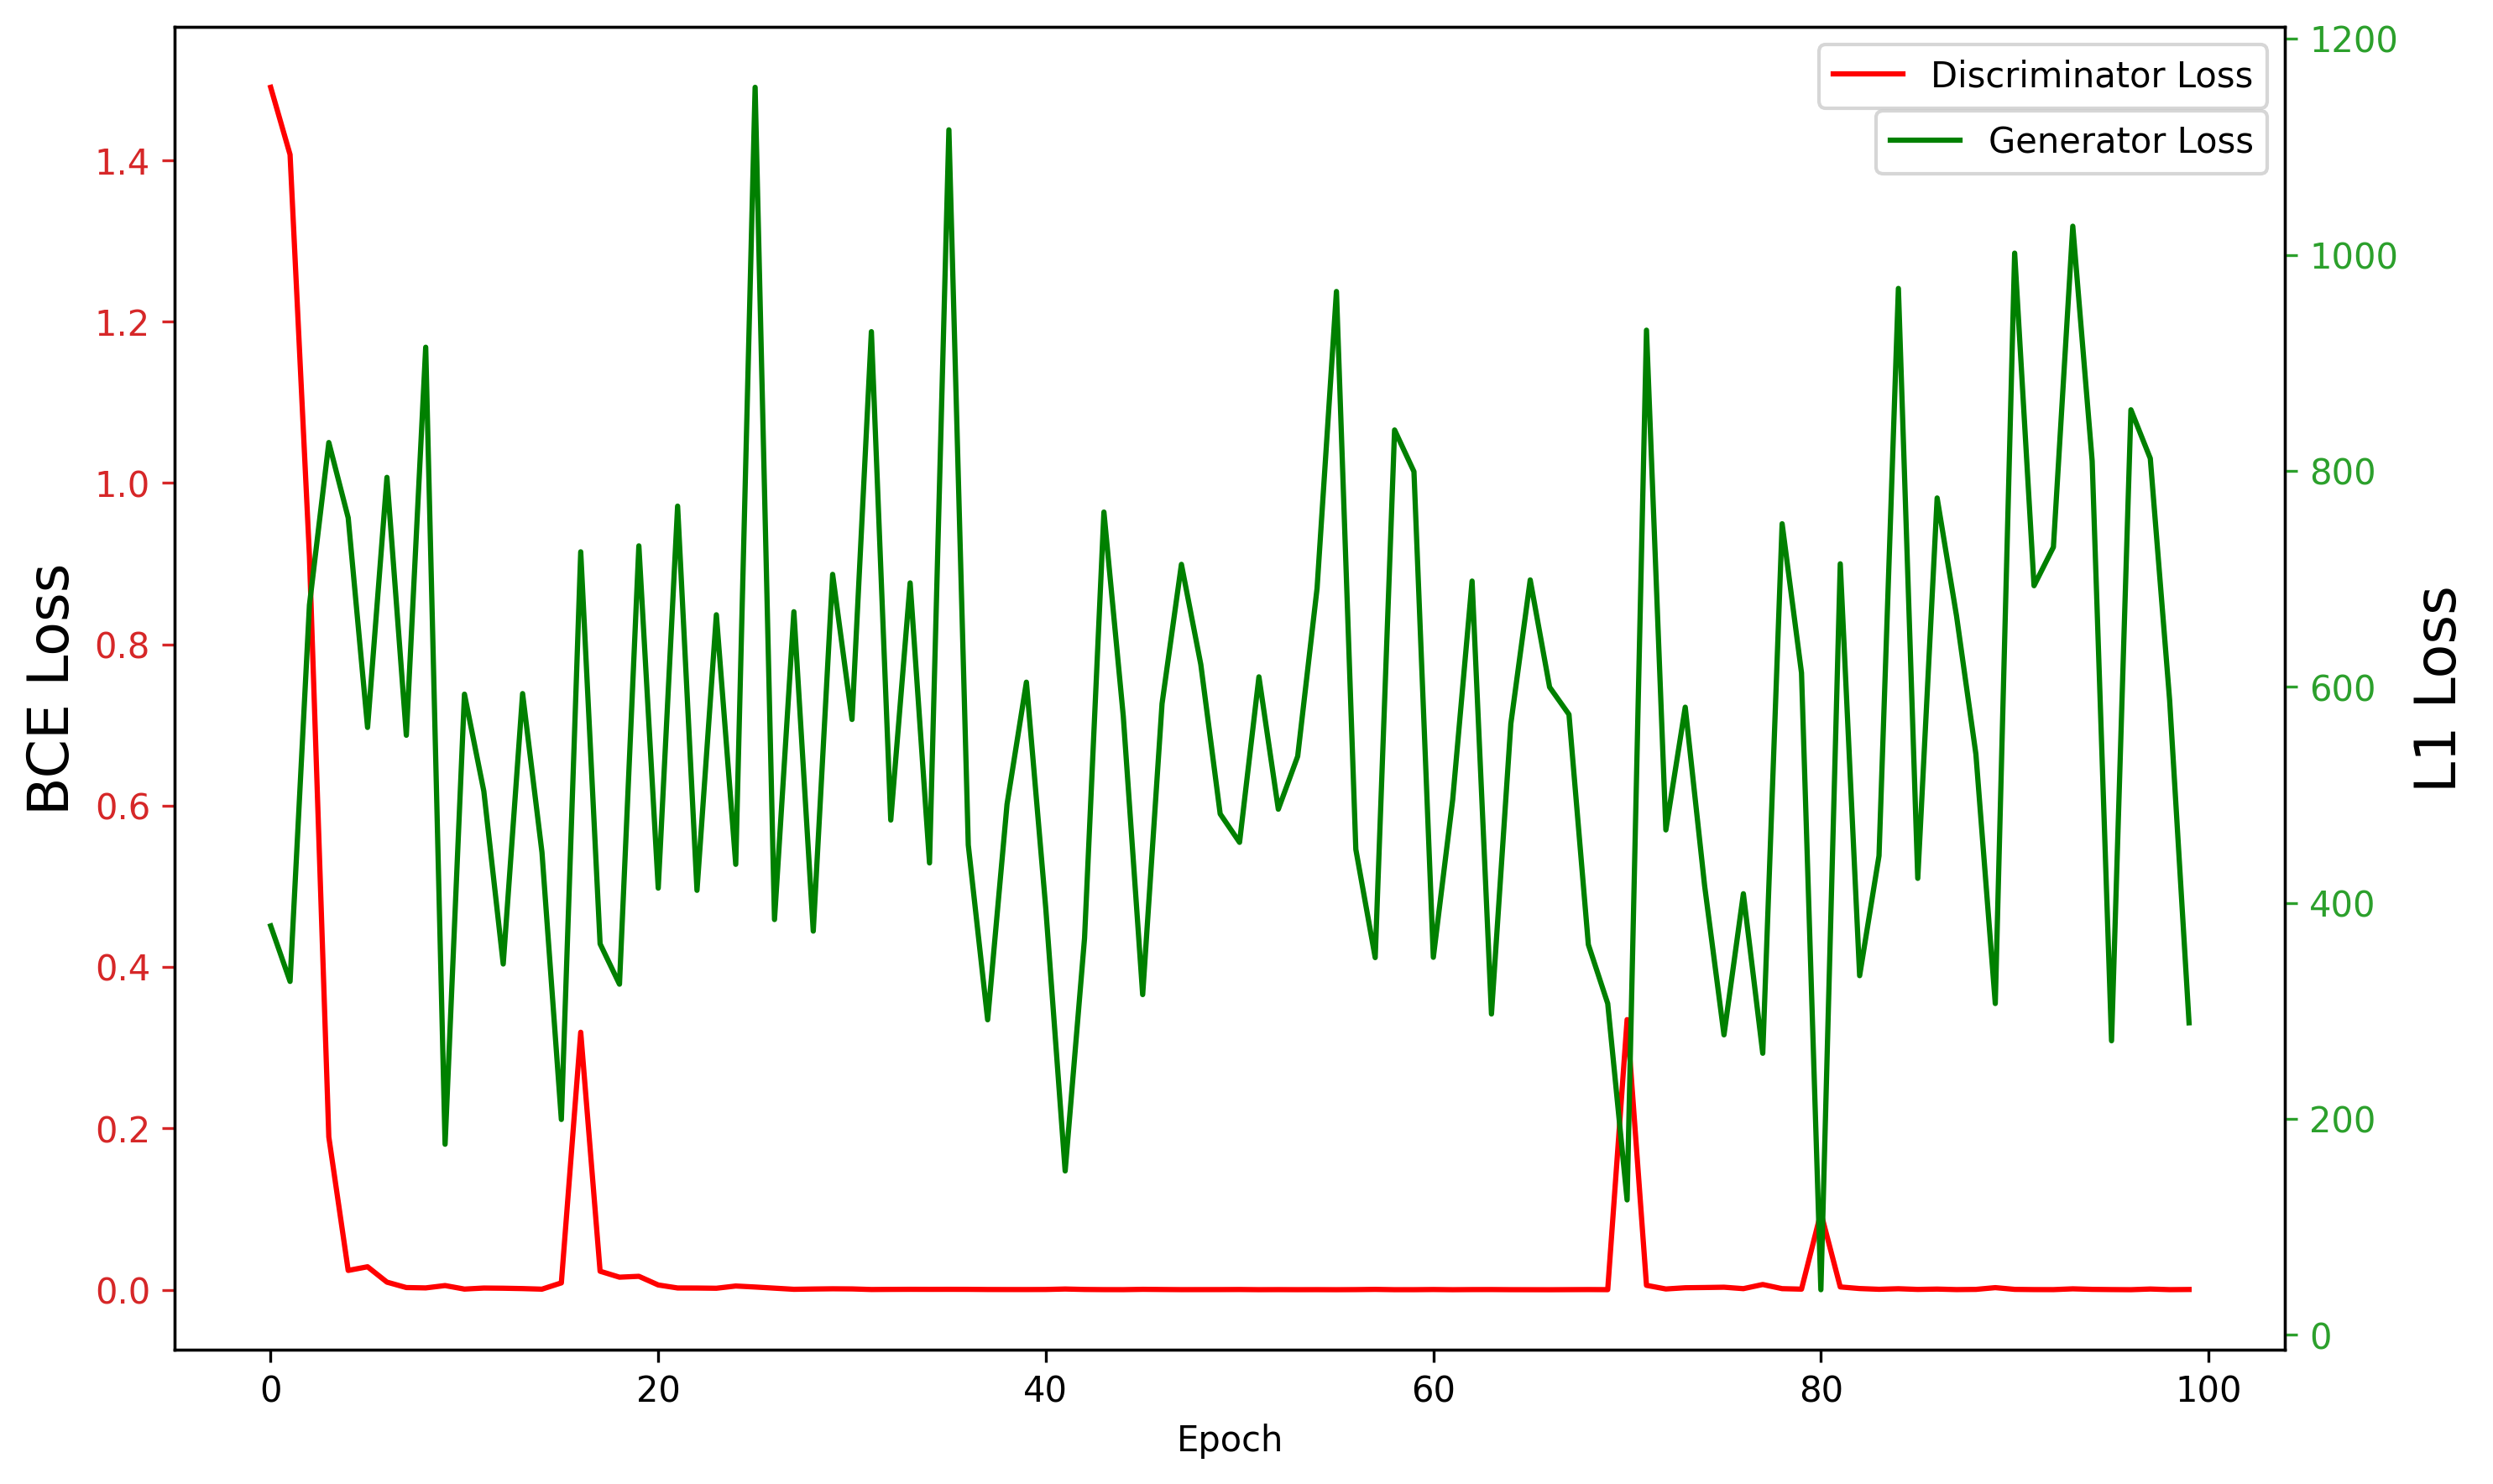

In [33]:
if DO_TRAINING:
    fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
    ax1.plot(d_loss_history, "r", label='Discriminator Loss')
    ax1.tick_params(axis="y", labelcolor="tab:red", color="tab:red")
    ax1.set_ylabel("BCE Loss", fontsize=16)
    ax1.legend(loc="upper right", bbox_to_anchor=[1, 1])
    ax1.set_xlabel("Epoch")

    ax2 = ax1.twinx() # Instatiate a second Axes that shares the x-axis

    ax2.plot(g_loss_history, "g", label='Generator Loss')
    ax2.tick_params(axis="y", labelcolor="tab:green", color="tab:green")
    ax2.set_ylabel("L1 Loss", fontsize=16)
    ax2.legend(loc='best', bbox_to_anchor=(1, 0.95))

    plt.tight_layout()

#### Downscale a Picture

In [63]:
# load weights
generator.load_state_dict(torch.load(f"generator_weights_{current_date}.pth"))

<All keys matched successfully>

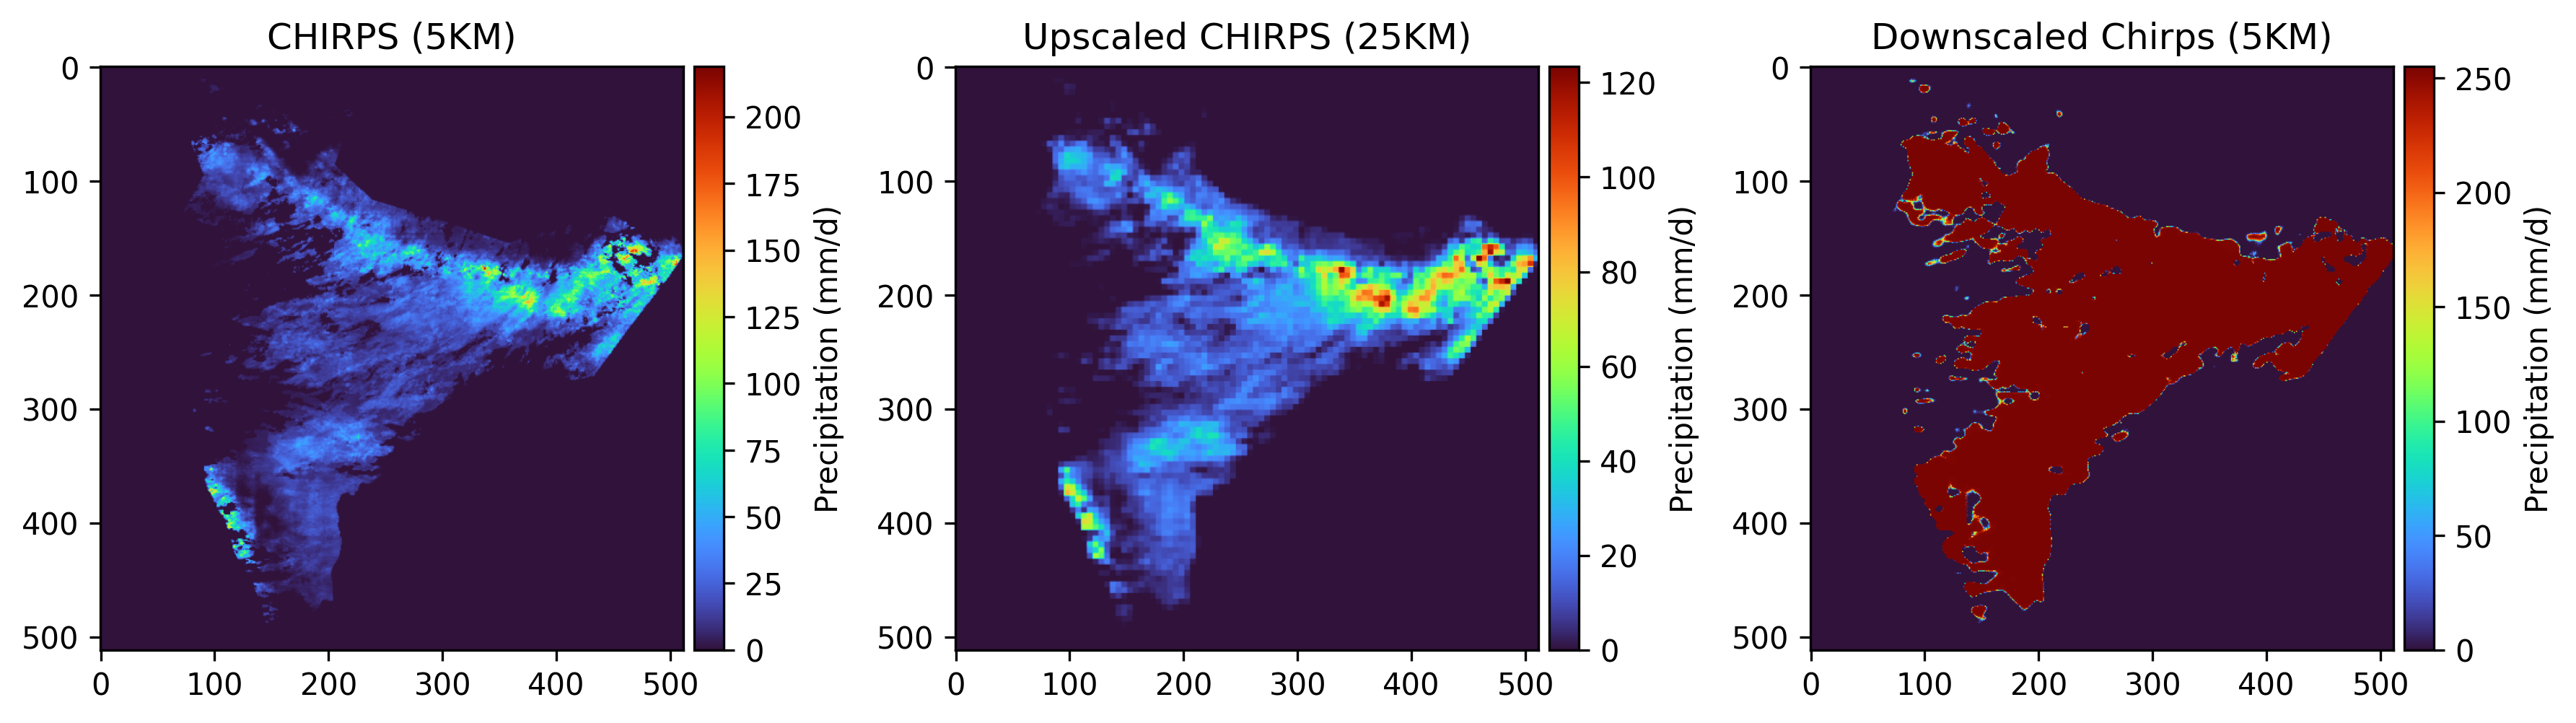

In [68]:
generator.eval()

i = 100

test_image = x_test[i]
min_val = test_image.min()
max_val = test_image.max()

true_image = y_test[i]

# test_image = trasform_image(test_image)
high_res_test_image = cv2.resize(test_image, (512, 512), interpolation=cv2.INTER_AREA)
# test_image_tensor = transforms.ToTensor()(high_res_test_image).unsqueeze(0).to(device)
test_image_tensor = transform(high_res_test_image).unsqueeze(0).to(device)
true_image_tensor = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    
])(true_image).unsqueeze(0).to(device)

with torch.no_grad():
    generated = generator(test_image_tensor)
# x_norm is in [-1, 1]
generated = (generated*0.5 + 0.5)


# generated = (generated)  # Back to picture colors

# output = model(tensor.unsqueeze(0))  # shape: [1, 3, H, W]
# output = output.squeeze(0).detach().cpu()

# If normalized, denormalize first
# generated = torch.clamp(generated, -1, 1)
# generated = (generated + 1)
# generated = generated.squeeze(0).cpu().byte()
# generated = (generated + 1) * (max_val - min_val)/2 + min_val
# generated = generated**2
# generated_img = transforms.ToPILImage()(generated/255 -1)
# generated_img = (np.array(generated_img).astype(np.float32)/255 -1)
generated_img = v2.ToPILImage()(generated.squeeze(0))
# generated_img.save('nice_downscaled.png')

fig,axs = plt.subplots(1,3,figsize=(12,7), dpi=300)
image_0 = axs[0].imshow(true_image, cmap="turbo")
axs[0].set_title("CHIRPS (5KM)")

divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size='5%', pad=0.05)
plt.colorbar(image_0, cax=cax, label="Precipitation (mm/d)")

image_1 = axs[1].imshow(high_res_test_image, cmap="turbo")
axs[1].set_title("Upscaled CHIRPS (25KM)")

divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size='5%', pad=0.05)
plt.colorbar(image_1, cax=cax, label="Precipitation (mm/d)")

image_2 = axs[2].imshow(generated_img, cmap="turbo")
axs[2].set_title("Downscaled Chirps (5KM)")

divider = make_axes_locatable(axs[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(image_2, cax=cax, label="Precipitation (mm/d)")

plt.tight_layout()
# plt.savefig("output.png")

In [24]:
discriminator.eval()
real_pred = discriminator(test_image_tensor, true_image_tensor)
gan_loss(real_pred, torch.ones_like(real_pred))

tensor(6.5401, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)

In [25]:
# noise = np.random.normal(0.5, 0.5, size=(512,512)).astype(np.float32)
# # Convert to tensor
# noise_tensor = transforms.ToTensor()(noise).unsqueeze(0).to(device)
# noise_tensor = transforms.Normalize((0.5,), (0.5,))(noise_tensor)

In [26]:
# with torch.no_grad():
#     out = generator(noise_tensor)
# out = (out*0.5 + 0.5) * 255
# out_img = transforms.ToPILImage()(out.squeeze(0).cpu().byte())
# fig, axs = plt.subplots(1, 2, figsize=(12, 7))
# axs[0].imshow(true_image, cmap="turbo")
# axs[0].set_title("Noise")
# axs[1].imshow(out_img, cmap="turbo")
# axs[1].set_title("Generated")

MSE=14320.310
Frobenius Norm=61269.738


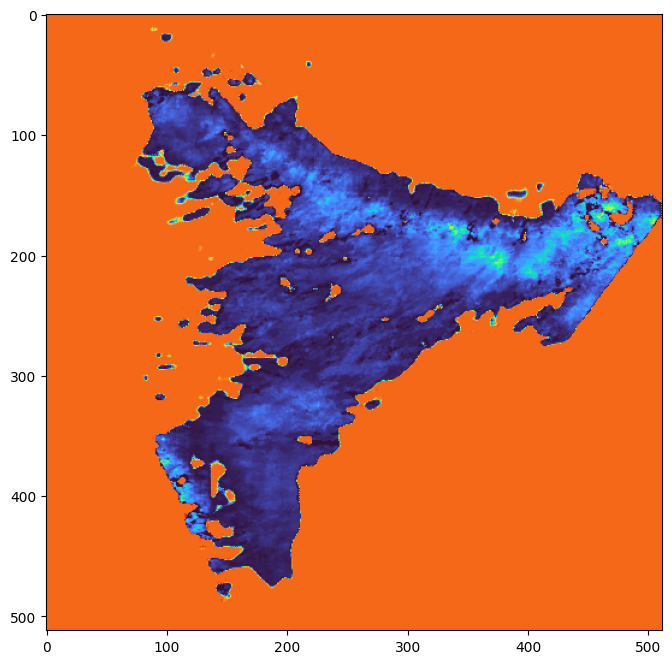

In [27]:
difference = true_image - generated_img
fro_norm = np.linalg.norm(difference,'fro')
mse = np.mean(difference**2)
plt.imshow(difference, cmap="turbo")
print(f"MSE={mse:0.3f}\nFrobenius Norm={fro_norm:0.3f}")